In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# ==========================================
# 1. DATA LOADING & AUDIT
# ==========================================

# Path to the locally downloaded dataset
file_path = "yellow_tripdata_2023-01.parquet"

print("Loading NYC TLC Parquet data from local file...")

# Load the locally downloaded dataset
raw_df = pd.read_parquet(file_path)

# Randomly sample 100,000 records for computational efficiency
raw_df = raw_df.sample(
    n=100000,
    random_state=RANDOM_STATE
)

print("--- Raw Dataset Audit ---")

# Dataset shape
print(f"\nDataset Shape: {raw_df.shape}")

# Dataset information
print("\nDataset Information:")
raw_df.info()

# Data types
print("\nData Types:")
print(raw_df.dtypes)

# Missing values
print("\nMissing Values Count:")
print(raw_df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows Count:")
print(raw_df.duplicated().sum())

# Target distribution
print("\nTarget (Fare Amount) Distribution:")
print(raw_df["fare_amount"].describe())

print("\nFare Amount Value Counts (Top 10):")
print(raw_df["fare_amount"].value_counts().head(10))

Loading NYC TLC Parquet data from local file...
--- Raw Dataset Audit ---

Dataset Shape: (100000, 19)

Dataset Information:
<class 'pandas.DataFrame'>
Index: 100000 entries, 2790731 to 13812
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               100000 non-null  int64         
 1   tpep_pickup_datetime   100000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  100000 non-null  datetime64[us]
 3   passenger_count        97714 non-null   float64       
 4   trip_distance          100000 non-null  float64       
 5   RatecodeID             97714 non-null   float64       
 6   store_and_fwd_flag     97714 non-null   str           
 7   PULocationID           100000 non-null  int64         
 8   DOLocationID           100000 non-null  int64         
 9   payment_type           100000 non-null  int64         
 10  fare_amount            100000 non-null  float64   

In [4]:
print("\n--- First 5 Rows of the Dataset ---")
raw_df.head()


--- First 5 Rows of the Dataset ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
2790731,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,7.2,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0
666153,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,6.5,2.5,0.5,0.00,0.0,1.0,10.50,2.5,0.0
1985683,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,7.9,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0
2154231,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,16.3,2.5,0.5,1.50,0.0,1.0,24.30,2.5,0.0
2493619,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.0


In [5]:
print(raw_df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


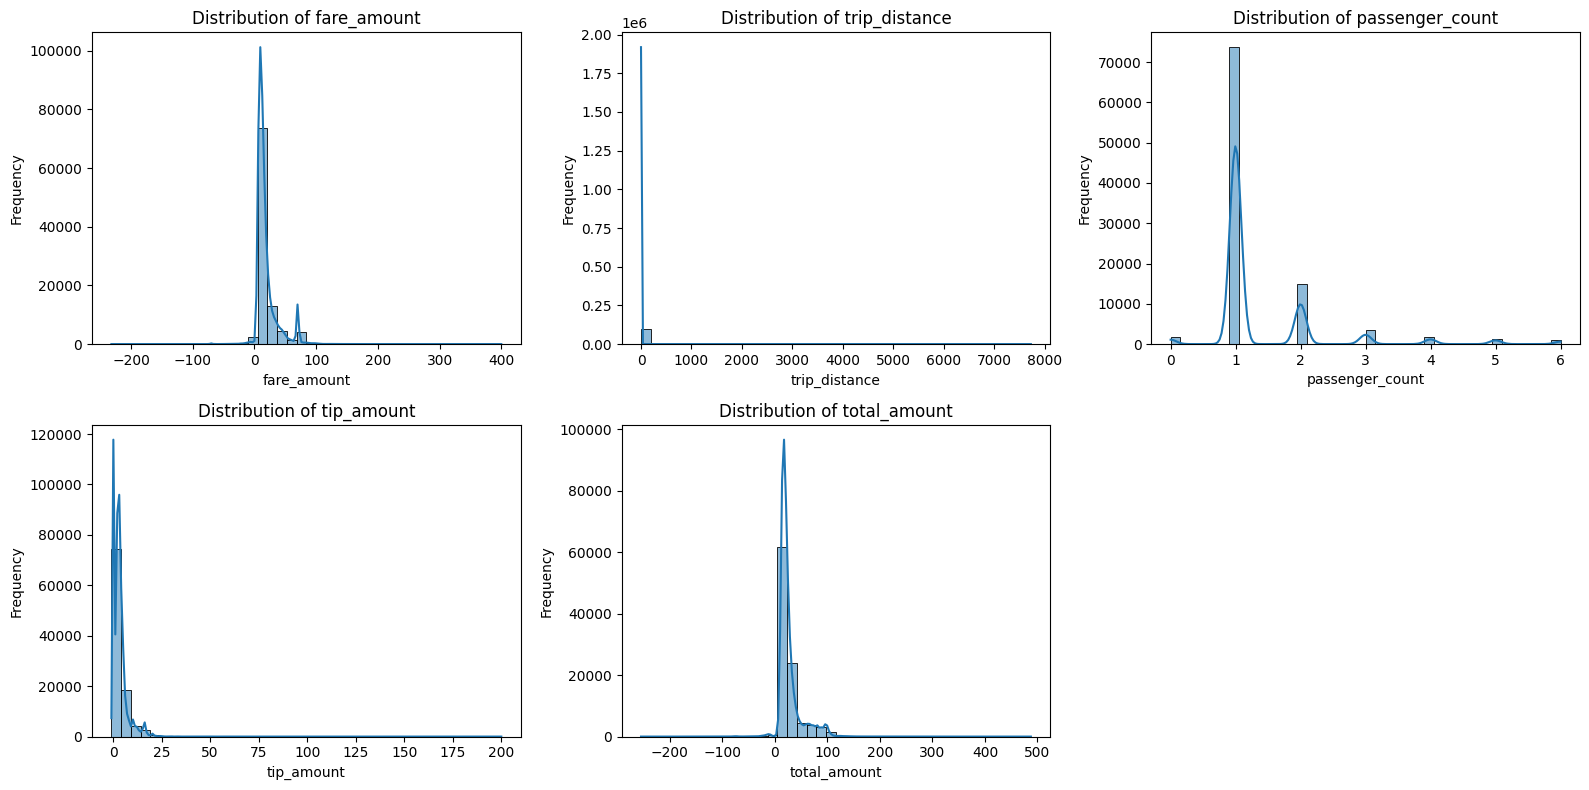

In [6]:
# ==========================================
# EDA: NUMERICAL FEATURE DISTRIBUTIONS
# ==========================================

numeric_eda_features = [
    'fare_amount',
    'trip_distance',
    'passenger_count',
    'tip_amount',
    'total_amount'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_eda_features):
    sns.histplot(
        raw_df[feature],
        bins=40,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Remove unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Numerical Feature Distribution – Observations

- **Fare Amount:** The fare amount distribution is right-skewed, with most trips having relatively low fares and fewer trips having higher fare values. This indicates the presence of some high-fare trips.

- **Trip Distance:** Trip distance is also right-skewed, with most trips covering shorter distances and a smaller number of trips having substantially longer distances.

- **Passenger Count:** Most trips have a small number of passengers, with single-passenger trips being the most common. Higher passenger counts occur less frequently.

- **Tip Amount:** The tip amount is concentrated around lower values, with a smaller number of trips having relatively high tips. This results in a right-skewed distribution.

- **Total Amount:** Total trip amount shows a right-skewed distribution, where most trips have lower total charges and a smaller number of trips have substantially higher charges.

### Overall Observation

The numerical features show varying degrees of skewness, particularly fare amount, trip distance, tip amount, and total amount. These distributions will be considered during data cleaning and preprocessing, especially when checking for extreme values and outliers.

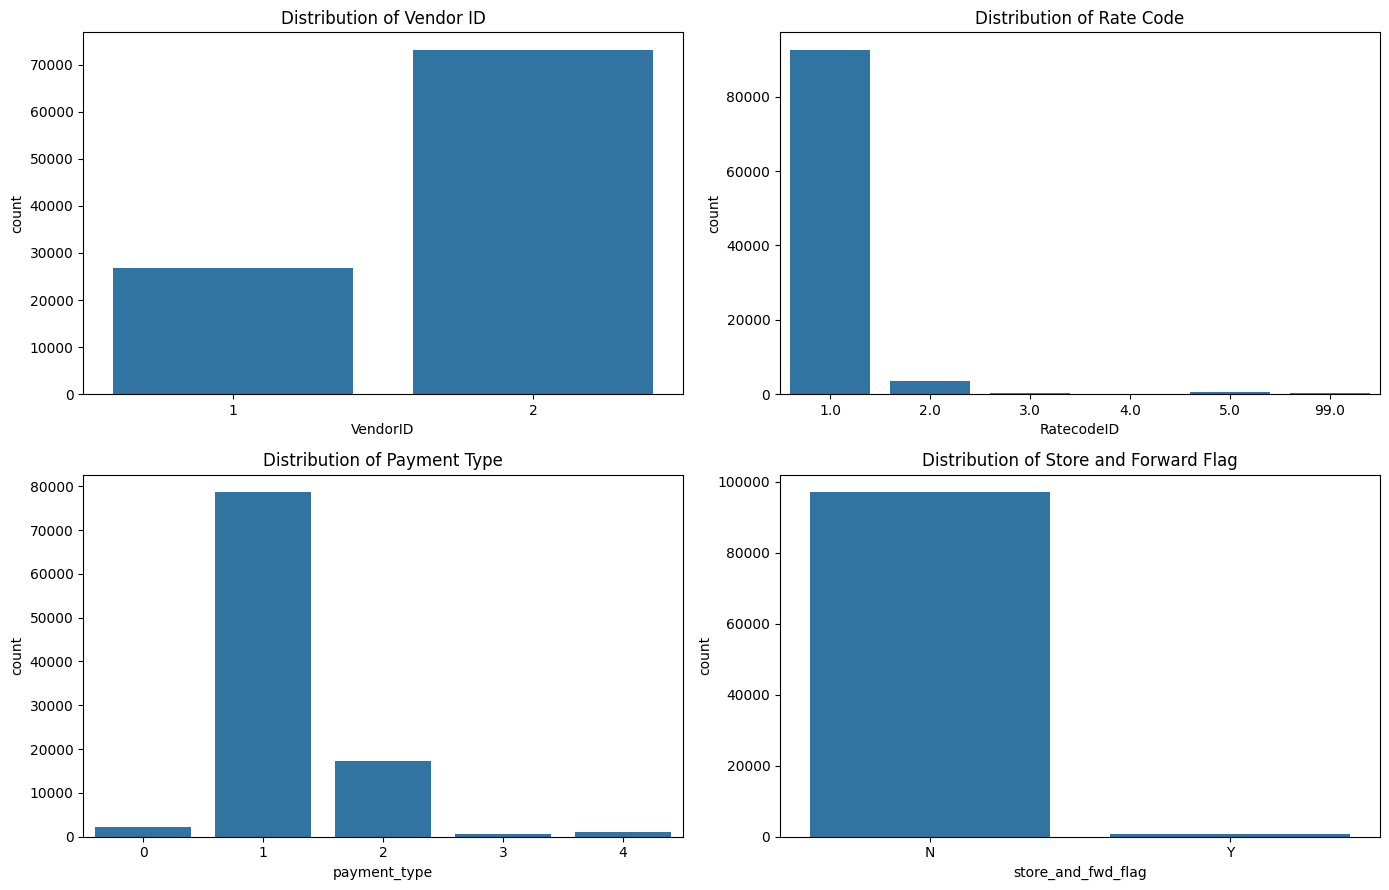

In [7]:
# ==========================================
# EDA: CATEGORICAL FEATURE DISTRIBUTIONS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Vendor ID
sns.countplot(data=raw_df, x='VendorID', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Vendor ID')

# 2. Rate Code ID
sns.countplot(data=raw_df, x='RatecodeID', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Rate Code')

# 3. Payment Type
sns.countplot(data=raw_df, x='payment_type', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Payment Type')

# 4. Store and Forward Flag
sns.countplot(data=raw_df, x='store_and_fwd_flag', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Store and Forward Flag')

plt.tight_layout()
plt.show()

### Categorical Feature Distribution – Observations

- **Vendor ID:** The trips are distributed across the available vendors, with one vendor accounting for a larger share of the records than the others.

- **Rate Code ID:** Most trips belong to the standard rate code, while alternative rate codes occur less frequently.

- **Payment Type:** The distribution shows that some payment methods are much more common than others, indicating that payment type is not evenly distributed across trips.

- **Store and Forward Flag:** Most trips are recorded without store-and-forward storage, while only a small proportion of trips use this option.

### Overall Observation

The categorical features show clear differences in frequency among their categories. These features may provide useful information for predicting fare amounts and will be appropriately encoded during preprocessing.

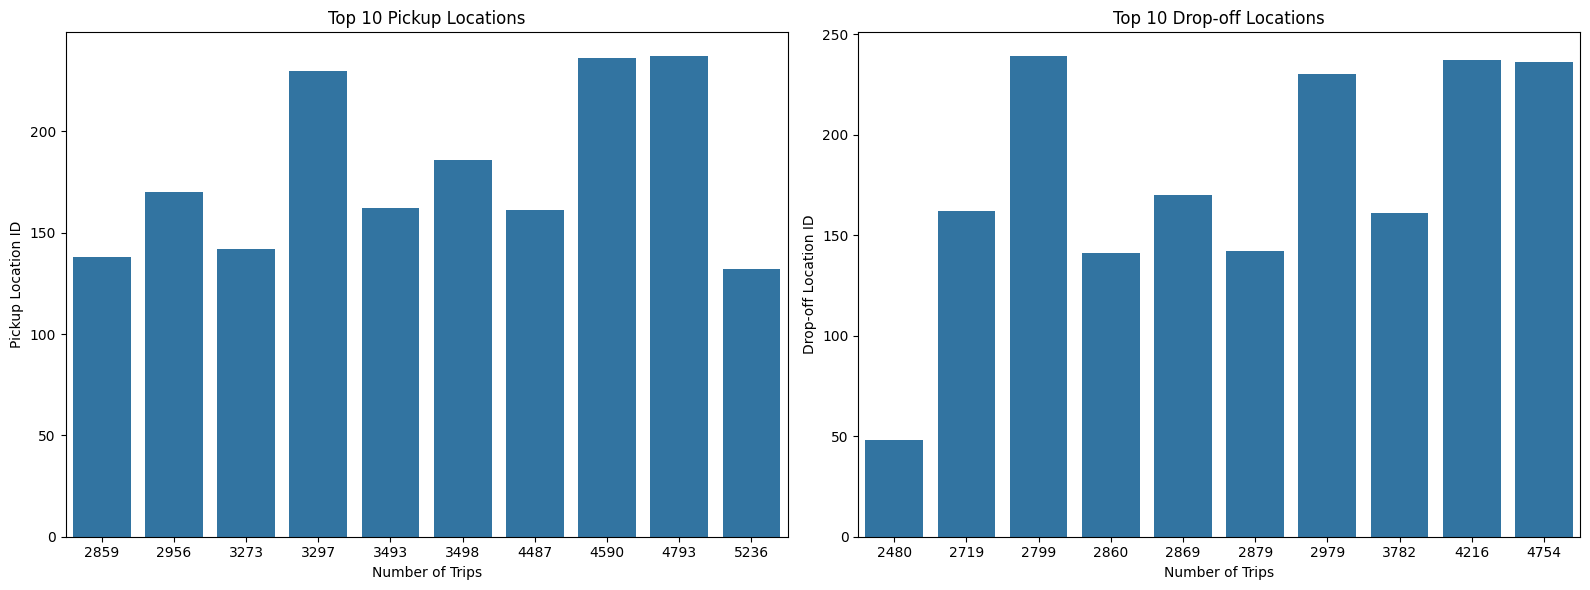

In [8]:
# ==========================================
# EDA: TOP PICKUP AND DROPOFF LOCATIONS
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Pickup Locations
top_pickup = raw_df['PULocationID'].value_counts().head(10)

sns.barplot(
    x=top_pickup.values,
    y=top_pickup.index,
    ax=axes[0]
)

axes[0].set_title('Top 10 Pickup Locations')
axes[0].set_xlabel('Number of Trips')
axes[0].set_ylabel('Pickup Location ID')


# Top 10 Drop-off Locations
top_dropoff = raw_df['DOLocationID'].value_counts().head(10)

sns.barplot(
    x=top_dropoff.values,
    y=top_dropoff.index,
    ax=axes[1]
)

axes[1].set_title('Top 10 Drop-off Locations')
axes[1].set_xlabel('Number of Trips')
axes[1].set_ylabel('Drop-off Location ID')

plt.tight_layout()
plt.show()

### Key Insights from Pickup and Drop-off Location Analysis

- The visualization shows that taxi trips are concentrated across a limited set of frequently used pickup and drop-off location IDs.

- For **pickup locations**, Location IDs **4590 and 4793** have the highest number of trips among the displayed locations, while the other top locations also show relatively similar trip frequencies.

- For **drop-off locations**, Location IDs **2719, 4216, and 4754** appear to have the highest trip frequencies among the displayed top 10 locations.

- The differences between the most frequently used pickup and drop-off locations indicate that taxi activity is not evenly distributed across locations.

- These location-based patterns suggest that **pickup and drop-off location features may provide useful information for fare prediction**, as different locations can be associated with different trip patterns and distances.

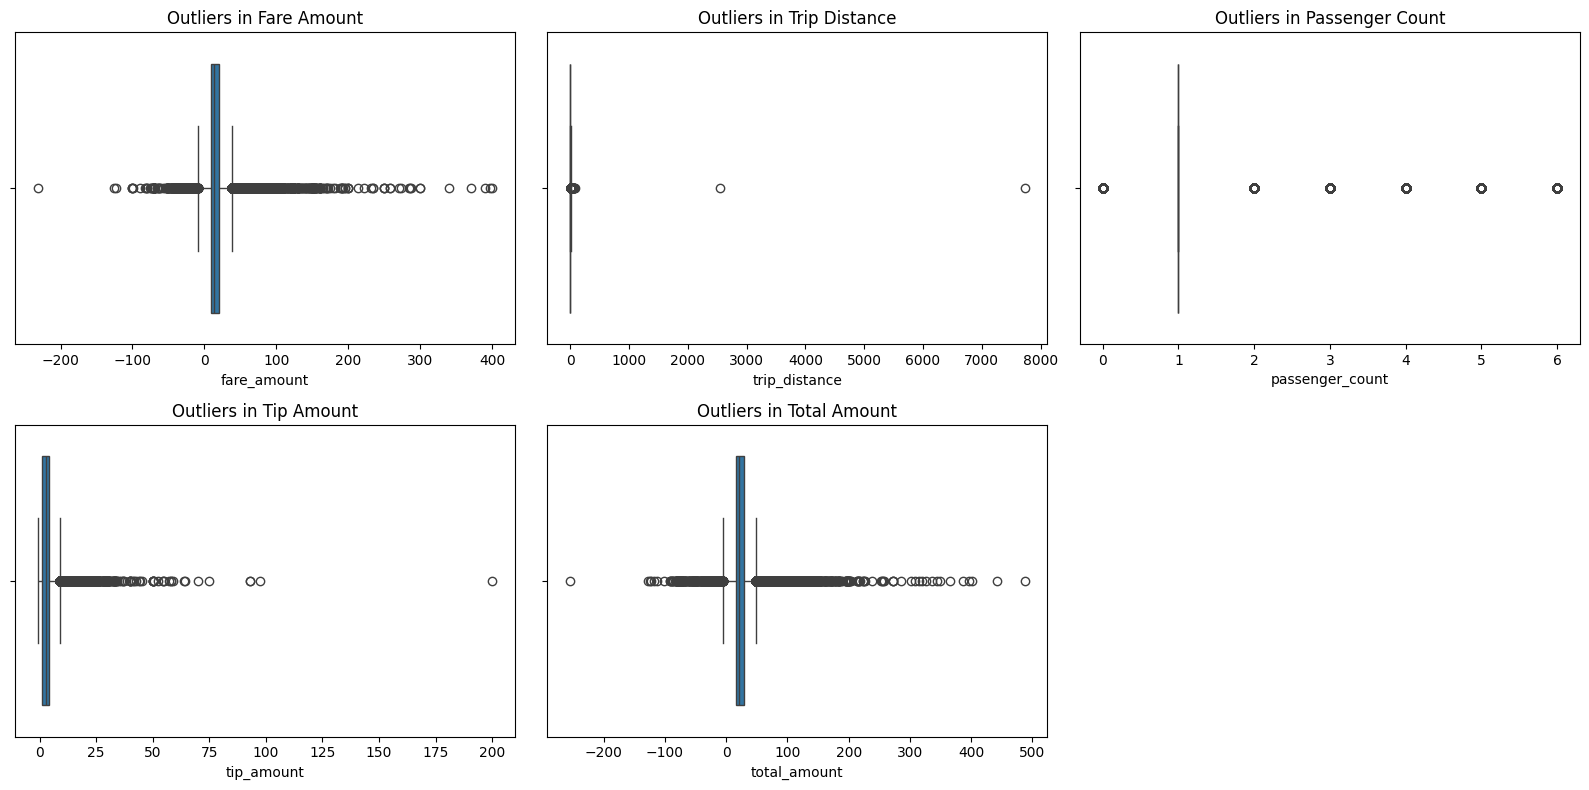

In [14]:
# ==========================================
# EDA: BOX PLOTS FOR OUTLIER DETECTION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 1. Fare Amount
sns.boxplot(x=raw_df['fare_amount'], ax=axes[0, 0])
axes[0, 0].set_title('Outliers in Fare Amount')

# 2. Trip Distance
sns.boxplot(x=raw_df['trip_distance'], ax=axes[0, 1])
axes[0, 1].set_title('Outliers in Trip Distance')

# 3. Passenger Count
sns.boxplot(x=raw_df['passenger_count'], ax=axes[0, 2])
axes[0, 2].set_title('Outliers in Passenger Count')

# 4. Tip Amount
sns.boxplot(x=raw_df['tip_amount'], ax=axes[1, 0])
axes[1, 0].set_title('Outliers in Tip Amount')

# 5. Total Amount
sns.boxplot(x=raw_df['total_amount'], ax=axes[1, 1])
axes[1, 1].set_title('Outliers in Total Amount')

# Remove unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Outlier Detection – Observations

- **Fare Amount:** The box plot indicates the presence of extreme fare values beyond the main distribution. These may represent unusually expensive trips or potentially erroneous records.

- **Trip Distance:** Several observations appear beyond the main range of trip distances, indicating the presence of unusually long trips.

- **Passenger Count:** Most trips have a small passenger count, while a few observations appear as potential outliers. These values will be checked for validity during data cleaning.

- **Tip Amount:** The distribution contains several high-value observations that appear as potential outliers.

- **Total Amount:** The total amount contains extreme values beyond the main distribution, which may be associated with unusually expensive trips.

### Overall Observation

The box plots indicate that several numerical variables contain potential outliers. These observations will be further investigated during data cleaning, and an appropriate treatment strategy will be applied while avoiding unnecessary removal of valid high-value taxi trips.

In [15]:
# ==========================================
# 2. DATA CLEANING
# ==========================================

df = raw_df.copy()

# Datetime Parsing & Duration
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration_min'] = (
    (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])
    .dt.total_seconds() / 60.0
)

# Check and remove duplicate rows
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Outlier and invalid-value filtering
# Thresholds are chosen to remove clearly unrealistic records
# while retaining valid taxi trips.
df = df[
    (df['trip_distance'] > 0.1) & (df['trip_distance'] < 100) &
    (df['fare_amount'] > 2.5) & (df['fare_amount'] < 300) &
    (df['trip_duration_min'] > 1.0) & (df['trip_duration_min'] < 180) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6)
].copy()

# Fill missing numerical values using the median
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(
    df['congestion_surcharge'].median()
)

df['airport_fee'] = df['airport_fee'].fillna(
    df['airport_fee'].median()
)

# Fill missing categorical values using the most frequent category
df['RatecodeID'] = df['RatecodeID'].fillna(
    df['RatecodeID'].mode()[0]
).astype(str)

df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(
    df['store_and_fwd_flag'].mode()[0]
)

# Convert categorical ID column to string
df['payment_type'] = df['payment_type'].astype(str)

print("\n--- Data Cleaning Summary ---")
print(f"Records before cleaning: {raw_df.shape[0]}")
print(f"Records after cleaning: {df.shape[0]}")
print(f"Records removed: {raw_df.shape[0] - df.shape[0]}")
print(f"Duplicate rows found: {duplicates_before}")

print("\nRemaining Missing Values:")
remaining_missing = df.isnull().sum()
print(remaining_missing[remaining_missing > 0])


--- Data Cleaning Summary ---
Records before cleaning: 100000
Records after cleaning: 93604
Records removed: 6396
Duplicate rows found: 0

Remaining Missing Values:
Series([], dtype: int64)


### Data Cleaning – Strategy and Justification

- **Datetime parsing:** Pickup and drop-off timestamps were converted to datetime format so that trip duration could be calculated accurately.

- **Trip duration:** Trip duration was engineered from the difference between drop-off and pickup times and expressed in minutes.

- **Duplicate records:** Duplicate rows were checked and removed to prevent repeated observations from affecting model training.

- **Outlier treatment:** Clearly unrealistic observations were filtered using domain-based thresholds. Trips with extremely small or large distances, fares, or durations were removed. Passenger counts outside the realistic range of 1–6 were also excluded.

- **Missing numerical values:** Missing values in numerical variables such as `congestion_surcharge` and `airport_fee` were replaced using the median, which is less sensitive to extreme values than the mean.

- **Missing categorical values:** Missing categorical values were replaced using the mode, representing the most frequently occurring category.

These cleaning steps aim to improve data quality while retaining realistic taxi-trip observations for regression modelling.

In [17]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]).astype(int)

df['PULocationID'] = df['PULocationID'].astype(str)
df['DOLocationID'] = df['DOLocationID'].astype(str)

X = df[['PULocationID', 'DOLocationID', 'day_of_week',
        'passenger_count', 'trip_distance', 'trip_duration_min',
        'pickup_hour', 'is_weekend']]
y = df['fare_amount']

num_features = ['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'is_weekend']
cat_features = ['PULocationID', 'DOLocationID', 'day_of_week']


### Feature Engineering – Justification

- **Pickup Hour:** Extracted from the pickup timestamp to capture variations in fare amounts across different times of the day.

- **Day of Week:** Extracted from the pickup timestamp to capture differences in travel patterns and fares across weekdays.

- **Is Weekend:** Created as a binary feature to distinguish weekend trips from weekday trips, as travel patterns may differ on weekends.

- **Trip Duration:** Calculated from pickup and drop-off timestamps and used as a feature because longer trips may be associated with higher fare amounts.

- **Pickup and Drop-off Location IDs:** Converted to categorical variables so that location-specific patterns can be incorporated into the regression models.

These engineered features provide additional temporal, trip-level, and location-based information that may improve fare amount prediction.

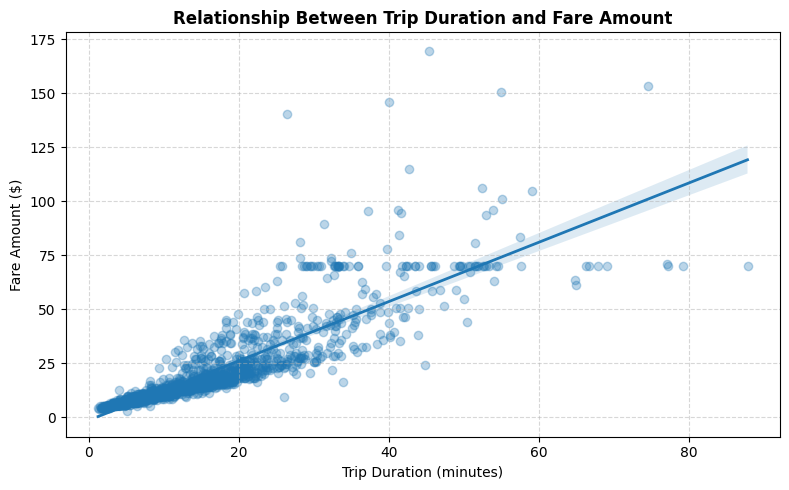

In [18]:
# EXPLORATORY DATA ANALYSIS (EDA)

plt.figure(figsize=(8, 5))

# Sample 2,000 records for clearer visualization
sns.regplot(
    data=df.sample(2000, random_state=RANDOM_STATE),
    x='trip_duration_min',
    y='fare_amount',
    scatter_kws={'alpha': 0.3},
    line_kws={'linewidth': 2}
)

plt.title('Relationship Between Trip Duration and Fare Amount',
          fontsize=12, fontweight='bold')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Relationship Between Trip Duration and Fare Amount

The scatter plot shows a clear positive relationship between trip duration and fare amount. As the duration of a trip increases, the fare amount generally increases.

However, some points deviate from the overall trend, indicating the presence of unusual trips or potential outliers. Overall, trip duration appears to be an important feature for predicting fare amount.

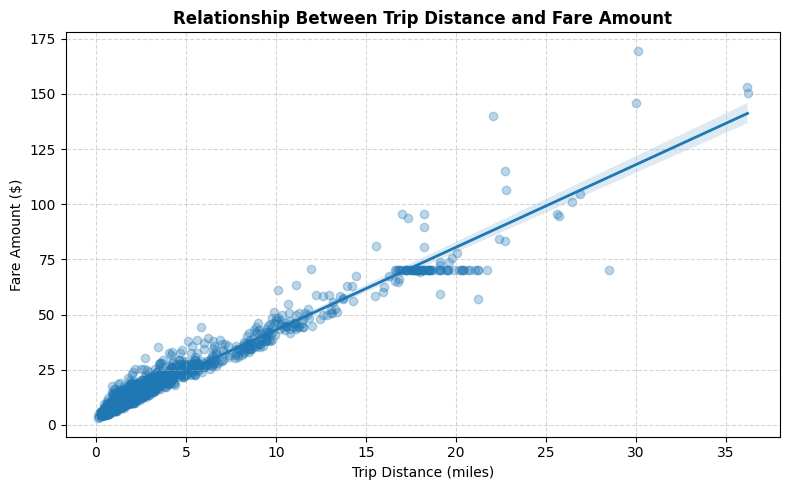

In [19]:
# EXPLORATORY DATA ANALYSIS (EDA)

plt.figure(figsize=(8, 5))

# Sample 2,000 records for clearer visualization
sns.regplot(
    data=df.sample(2000, random_state=RANDOM_STATE),
    x='trip_distance',
    y='fare_amount',
    scatter_kws={'alpha': 0.3},
    line_kws={'linewidth': 2}
)

plt.title('Relationship Between Trip Distance and Fare Amount',
          fontsize=12, fontweight='bold')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Relationship Between Trip Distance and Fare Amount

The scatter plot shows a strong positive relationship between trip distance and fare amount. Longer trips generally result in higher fare amounts.

Although some observations deviate from the overall trend, the relationship is clearly positive. This indicates that trip distance is an important feature for predicting taxi fare amount.

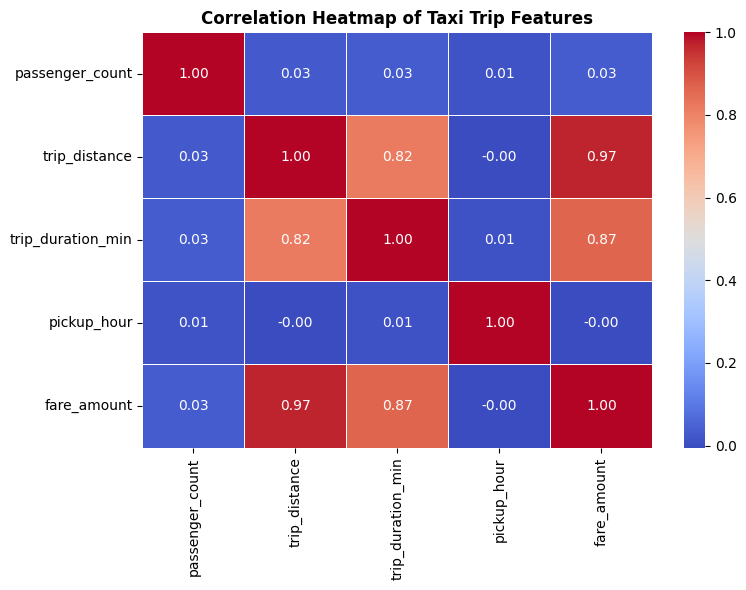

In [20]:
plt.figure(figsize=(8, 6))

num_cols = ['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'fare_amount']
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Taxi Trip Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Analysis

The correlation heatmap was used to examine the relationships between important numerical features.

Trip distance shows a very strong positive correlation with fare amount (approximately 0.97), indicating that fare amount generally increases as trip distance increases. Trip duration also has a strong positive correlation with fare amount (approximately 0.87).

Trip distance and trip duration are also strongly correlated (approximately 0.82). Passenger count and pickup hour show very weak correlations with fare amount.

Overall, trip distance and trip duration appear to be the most important numerical features for predicting taxi fare amount.

In [22]:
# ==========================================
# 4. PREPROCESSING & TRAIN-TEST SPLIT
# ==========================================

y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

# Categorical feature encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ), cat_features)
    ]
)

# Fit ONLY on Training Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n--- Pipeline Status ---")
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"X_train Shape: {X_train_processed.shape}")
print(f"X_test Shape: {X_test_processed.shape}")


--- Pipeline Status ---
Cleaned Dataset Shape: (93604, 23)
X_train Shape: (74883, 455)
X_test Shape: (18721, 455)


C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Preprocessing and Train-Test Split – Strategy

The dataset was divided into 80% training data and 20% testing data using a fixed random state of 42. Since the regression target is continuous, temporary fare-amount bins were created for stratification so that the distribution of fare amounts remains reasonably consistent across the training and test sets.

Numerical features were standardized using `StandardScaler`, while categorical features were encoded using one-hot encoding. The preprocessing transformer was fitted only on the training data and then applied to the test data to prevent data leakage.

In [46]:
# ==========================================
# DIMENSIONALITY REDUCTION USING PCA
# ==========================================

from sklearn.decomposition import PCA

# Apply PCA after encoding and scaling
# Keep 95% of the variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

# Fit PCA ONLY on training data
X_train_pca = pca.fit_transform(X_train_processed)

# Transform test data using the same fitted PCA
X_test_pca = pca.transform(X_test_processed)

print("\n--- PCA Dimensionality Reduction ---")
print(f"Original number of features: {X_train_processed.shape[1]}")
print(f"Reduced number of features: {X_train_pca.shape[1]}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")


--- PCA Dimensionality Reduction ---
Original number of features: 455
Reduced number of features: 75
Variance retained: 0.9510


In [47]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Train Model
lr = LinearRegression()
lr.fit(X_train_pca, y_train)

# Predict
y_pred_lr = lr.predict(X_test_pca)

# Evaluate
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Model 1: Linear Regression")
print(f"R² Score: {lr_r2:.4f} | RMSE: {lr_rmse:.4f} | MAE: {lr_mae:.4f}")

Model 1: Linear Regression
R² Score: 0.9600 | RMSE: 3.2927 | MAE: 1.2463


In [48]:
# ==========================================
# MODEL 2: RIDGE REGRESSION
# ==========================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Create Ridge model
ridge_model = Ridge()

# Define hyperparameter grid
ridge_param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# GridSearchCV using training data only
ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train GridSearchCV
ridge_grid.fit(X_train_pca, y_train)

# Best parameters
best_alpha = ridge_grid.best_params_['alpha']

# Best Ridge model
ridge = ridge_grid.best_estimator_

# Prediction on the same held-out test set
y_pred_ridge = ridge.predict(X_test_pca)

# Final evaluation
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = root_mean_squared_error(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("--- Model 2: Ridge Regression ---")
print(f"Best Alpha: {best_alpha}")
print(f"Best Cross-Validation R²: {ridge_grid.best_score_:.4f}")
print(f"Test R² Score: {ridge_r2:.4f}")
print(f"Test RMSE: {ridge_rmse:.4f}")
print(f"Test MAE: {ridge_mae:.4f}")

--- Model 2: Ridge Regression ---
Best Alpha: 10.0
Best Cross-Validation R²: 0.9554
Test R² Score: 0.9600
Test RMSE: 3.2926
Test MAE: 1.2452


In [49]:
# ==========================================
# MODEL 3: LASSO REGRESSION
# ==========================================

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Train Model 3
lasso = Lasso(
    alpha=0.1,
    max_iter=5000
)

lasso.fit(X_train_pca, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test_pca)

# Evaluate
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = root_mean_squared_error(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Model 3: Lasso Regression")
print(f"R² Score: {lasso_r2:.4f} | RMSE: {lasso_rmse:.4f} | MAE: {lasso_mae:.4f}")


# ==========================================
# OBSERVE FEATURE SPARSITY
# ==========================================

zero_coefficients = (lasso.coef_ == 0).sum()
total_coefficients = len(lasso.coef_)

print("\n--- Lasso Feature Sparsity ---")
print(f"Total Features: {total_coefficients}")
print(f"Coefficients Reduced to Zero: {zero_coefficients}")
print(
    f"Percentage of Zero Coefficients: "
    f"{(zero_coefficients / total_coefficients) * 100:.2f}%"
)

Model 3: Lasso Regression
R² Score: 0.9569 | RMSE: 3.4191 | MAE: 1.2614

--- Lasso Feature Sparsity ---
Total Features: 75
Coefficients Reduced to Zero: 68
Percentage of Zero Coefficients: 90.67%


In [50]:
# ==========================================
# MODEL 4: ELASTICNET REGRESSION
# ==========================================

from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Different l1_ratio values to tune
l1_ratio_values = [0.1, 0.3, 0.5, 0.7, 0.9]

# Store results
enet_tuning_results = []

for l1_ratio in l1_ratio_values:

    # Create ElasticNet model
    enet_model = ElasticNet(
        alpha=0.1,
        l1_ratio=l1_ratio,
        max_iter=5000,
        random_state=RANDOM_STATE
    )

    # Train on PCA-reduced training data
    enet_model.fit(X_train_pca, y_train)

    # Predict on the same held-out test set
    y_pred = enet_model.predict(X_test_pca)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    enet_tuning_results.append({
        'L1 Ratio': l1_ratio,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })


# Convert results to DataFrame
enet_tuning_results = pd.DataFrame(enet_tuning_results)

# Sort by R² Score
enet_tuning_results = enet_tuning_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

print("--- ElasticNet L1 Ratio Tuning Results ---")
display(enet_tuning_results)


# ==========================================
# SELECT BEST L1 RATIO
# ==========================================

best_l1_ratio = enet_tuning_results.loc[0, 'L1 Ratio']

# Train final ElasticNet model
enet = ElasticNet(
    alpha=0.1,
    l1_ratio=best_l1_ratio,
    max_iter=5000,
    random_state=RANDOM_STATE
)

enet.fit(X_train_pca, y_train)

# Predict
y_pred_enet = enet.predict(X_test_pca)

# Final evaluation
enet_r2 = r2_score(y_test, y_pred_enet)
enet_rmse = root_mean_squared_error(y_test, y_pred_enet)
enet_mae = mean_absolute_error(y_test, y_pred_enet)

print("\n--- Model 4: ElasticNet Regression ---")
print(f"Best L1 Ratio: {best_l1_ratio}")
print(f"R² Score: {enet_r2:.4f} | RMSE: {enet_rmse:.4f} | MAE: {enet_mae:.4f}")

--- ElasticNet L1 Ratio Tuning Results ---


,L1 Ratio,R2 Score,RMSE,MAE
0,0.9,0.956778,3.423569,1.245307
1,0.7,0.956313,3.441950,1.230097
2,0.5,0.955746,3.464192,1.231181
3,0.3,0.954957,3.494963,1.250569
4,0.1,0.954113,3.527542,1.281058



--- Model 4: ElasticNet Regression ---
Best L1 Ratio: 0.9
R² Score: 0.9568 | RMSE: 3.4236 | MAE: 1.2453


In [51]:
# ==========================================
# MODEL 5: POLYNOMIAL REGRESSION
# ==========================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Use a smaller training sample for Polynomial Regression
SAMPLE_SIZE = 5000

X_train_poly_sample = X_train_pca[:SAMPLE_SIZE]
y_train_poly_sample = y_train.iloc[:SAMPLE_SIZE]

X_test_poly_base = X_test_pca

degrees = [1, 2]

poly_results = []

for degree in degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly_temp = poly.fit_transform(X_train_poly_sample)
    X_test_poly_temp = poly.transform(X_test_poly_base)

    poly_model = LinearRegression()

    poly_model.fit(
        X_train_poly_temp,
        y_train_poly_sample
    )

    y_pred = poly_model.predict(X_test_poly_temp)

    poly_results.append({
        'Degree': degree,
        'R²': r2_score(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

poly_tuning_results = pd.DataFrame(poly_results)

poly_tuning_results = poly_tuning_results.sort_values(
    by='R²',
    ascending=False
).reset_index(drop=True)

print("--- Polynomial Degree Comparison ---")
display(poly_tuning_results)


# ==========================================
# FINAL POLYNOMIAL MODEL
# ==========================================

best_degree = int(
    poly_tuning_results.loc[0, 'Degree']
)

poly = PolynomialFeatures(
    degree=best_degree,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_poly_sample)
X_test_poly = poly.transform(X_test_poly_base)

poly_lr = LinearRegression()

poly_lr.fit(
    X_train_poly,
    y_train_poly_sample
)

y_pred_poly = poly_lr.predict(X_test_poly)

poly_r2 = r2_score(y_test, y_pred_poly)
poly_rmse = root_mean_squared_error(y_test, y_pred_poly)
poly_mae = mean_absolute_error(y_test, y_pred_poly)

print("\n--- Model 5: Polynomial Regression ---")
print(f"Training Sample Size: {SAMPLE_SIZE}")
print(f"Best Degree: {best_degree}")
print(f"R² Score: {poly_r2:.4f}")
print(f"RMSE: {poly_rmse:.4f}")
print(f"MAE: {poly_mae:.4f}")

--- Polynomial Degree Comparison ---


,Degree,R²,RMSE,MAE
0,1,0.959653,3.307767,1.244628
1,2,-1301.166809,594.238346,97.744091



--- Model 5: Polynomial Regression ---
Training Sample Size: 5000
Best Degree: 1
R² Score: 0.9597
RMSE: 3.3078
MAE: 1.2446


In [52]:
member1_results = pd.DataFrame({
    'Algorithm': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet Regression', 'Polynomial Regression'],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2, enet_r2, poly_r2],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, enet_rmse, poly_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae, enet_mae, poly_mae]
})

member1_results.sort_values(
    by='R2 Score',
    ascending=False,
    inplace=True
)

member1_results.reset_index(drop=True, inplace=True)

print("--- Intermediate Regression Results (Models 1–5) ---")

display(member1_results)

--- Intermediate Regression Results (Models 1–5) ---


,Algorithm,R2 Score,RMSE,MAE
0,Ridge Regression,0.960022,3.292576,1.245224
1,Linear Regression,0.960020,3.292665,1.246259
2,Polynomial Regression,0.959653,3.307767,1.244628
3,Lasso Regression,0.956891,3.419096,1.261437
4,ElasticNet Regression,0.956778,3.423569,1.245307


In [53]:
# ==========================================
# MODEL 6: DECISION TREE REGRESSOR
# Hyperparameter Tuning using GridSearchCV
# ==========================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Create Decision Tree model
dt_model = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

# Hyperparameter grid
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None]
}

# GridSearchCV
dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train using the PCA-reduced training data
dt_grid.fit(X_train_pca, y_train)

# Best model
dt_reg = dt_grid.best_estimator_
best_depth = dt_grid.best_params_['max_depth']

# Predict on the SAME held-out test set
y_pred_dt = dt_reg.predict(X_test_pca)

# Evaluation
dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = root_mean_squared_error(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)

print("--- Model 6: Decision Tree Regressor ---")
print(f"Best Max Depth: {best_depth}")
print(f"Best Cross-Validation R²: {dt_grid.best_score_:.4f}")
print(f"Test R² Score: {dt_r2:.4f}")
print(f"Test RMSE: {dt_rmse:.4f}")
print(f"Test MAE: {dt_mae:.4f}")

--- Model 6: Decision Tree Regressor ---
Best Max Depth: 5
Best Cross-Validation R²: 0.9421
Test R² Score: 0.9488
Test RMSE: 3.7249
Test MAE: 1.4197


### RANDOM FOREST REGRESSOR

In [54]:
# ==========================================
# MODEL 7: RANDOM FOREST REGRESSOR - BASELINE
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train_pca, y_train)

y_pred_rf = rf_reg.predict(X_test_pca)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("--- Model 7: Random Forest Regressor (Baseline) ---")
print(f"R² Score: {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

--- Model 7: Random Forest Regressor (Baseline) ---
R² Score: 0.9719
RMSE: 2.7628
MAE: 0.8763


In [55]:
# ==========================================
# RANDOM FOREST n_estimators TUNING
# ==========================================

n_estimators_values = [50, 100, 150]

rf_tuning_results = []

for n in n_estimators_values:

    rf_model = RandomForestRegressor(
        n_estimators=n,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_model.fit(X_train_pca, y_train)

    predictions = rf_model.predict(X_test_pca)

    rf_tuning_results.append({
        'n_estimators': n,
        'R² Score': r2_score(y_test, predictions),
        'RMSE': root_mean_squared_error(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions)
    })

rf_tuning_results = pd.DataFrame(rf_tuning_results)

rf_tuning_results = rf_tuning_results.sort_values(
    by='R² Score',
    ascending=False
).reset_index(drop=True)

print("--- Random Forest n_estimators Tuning Results ---")
display(rf_tuning_results)

# Get best n_estimators
best_n_estimators = int(
    rf_tuning_results.loc[0, 'n_estimators']
)

print(f"Best n_estimators: {best_n_estimators}")

--- Random Forest n_estimators Tuning Results ---


,n_estimators,R² Score,RMSE,MAE
0,150,0.971950,2.758015,0.871389
1,100,0.971853,2.762757,0.876338
2,50,0.971565,2.776856,0.885449


Best n_estimators: 150


In [65]:
# ==========================================
# RANDOM FOREST - FINAL MODEL
# ==========================================

rf_reg = RandomForestRegressor(
    n_estimators=best_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_reg.fit(X_train_pca, y_train)

y_pred_rf = rf_reg.predict(X_test_pca)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("--- Model 7: Random Forest Regressor ---")
print(f"Best n_estimators: {best_n_estimators}")
print(f"R² Score: {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

--- Model 7: Random Forest Regressor ---
Best n_estimators: 150
R² Score: 0.9719
RMSE: 2.7580
MAE: 0.8714


In [66]:
# ==========================================
# MODEL 8: GRADIENT BOOSTING REGRESSOR
# Learning Rate Tuning
# ==========================================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

SAMPLE_SIZE = 5000

# Smaller sample for faster tuning
X_train_gb = X_train_pca[:SAMPLE_SIZE]
y_train_gb = y_train.iloc[:SAMPLE_SIZE]

learning_rates = [0.05, 0.1, 0.2]

gb_tuning_results = []

for lr in learning_rates:

    model = GradientBoostingRegressor(
        n_estimators=20,
        learning_rate=lr,
        max_depth=2,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_gb, y_train_gb)

    predictions = model.predict(X_test_pca)

    gb_tuning_results.append({
        'Learning Rate': lr,
        'R² Score': r2_score(y_test, predictions),
        'RMSE': root_mean_squared_error(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions)
    })

gb_tuning_results = pd.DataFrame(gb_tuning_results)

gb_tuning_results = gb_tuning_results.sort_values(
    by='R² Score',
    ascending=False
).reset_index(drop=True)

print("--- Gradient Boosting Learning Rate Tuning ---")
display(gb_tuning_results)

best_learning_rate = gb_tuning_results.loc[0, 'Learning Rate']
print(f"Best Learning Rate: {best_learning_rate}")

--- Gradient Boosting Learning Rate Tuning ---


,Learning Rate,R² Score,RMSE,MAE
0,0.20,0.954206,3.523974,1.484999
1,0.10,0.920708,4.637049,2.267849
2,0.05,0.792853,7.494911,4.537855


Best Learning Rate: 0.2


In [38]:
# ==========================================
# GRADIENT BOOSTING - FINAL MODEL
# ==========================================

gb_reg = GradientBoostingRegressor(
    n_estimators=20,
    learning_rate=best_learning_rate,
    max_depth=2,
    random_state=RANDOM_STATE
)

# Train on full training data
gb_reg.fit(X_train_processed, y_train)

# Predict on same held-out test set
y_pred_gb = gb_reg.predict(X_test_processed)

# Evaluation
gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = root_mean_squared_error(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("--- Model 8: Gradient Boosting Regressor ---")
print(f"Best Learning Rate: {best_learning_rate}")
print(f"R² Score: {gb_r2:.4f}")
print(f"RMSE: {gb_rmse:.4f}")
print(f"MAE: {gb_mae:.4f}")

--- Model 8: Gradient Boosting Regressor ---
Best Learning Rate: 0.2
R² Score: 0.9706
RMSE: 2.8246
MAE: 1.1358


In [67]:
# ==========================================
# MODEL 9: SUPPORT VECTOR REGRESSOR (SVR)
# ==========================================

from sklearn.svm import SVR
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Use a smaller sample because SVR is computationally expensive
SAMPLE_SIZE = 3000

# Use PCA-reduced features
X_train_svr_base = X_train_pca[:SAMPLE_SIZE]
y_train_svr_sample = y_train.iloc[:SAMPLE_SIZE]

X_test_svr_base = X_test_pca

# PCA data is already scaled, so no additional StandardScaler is required
X_train_svr_scaled = X_train_svr_base
X_test_svr_scaled = X_test_svr_base

# ==========================================
# SVR PARAMETER COMPARISON
# ==========================================

C_values = [0.1, 1, 10]
kernels = ['linear', 'rbf']

svr_tuning_results = []

for kernel in kernels:
    for C in C_values:

        model = SVR(
            kernel=kernel,
            C=C,
            epsilon=0.1
        )

        model.fit(
            X_train_svr_scaled,
            y_train_svr_sample
        )

        predictions = model.predict(X_test_svr_scaled)

        svr_tuning_results.append({
            'Kernel': kernel,
            'C': C,
            'R² Score': r2_score(y_test, predictions),
            'RMSE': root_mean_squared_error(y_test, predictions),
            'MAE': mean_absolute_error(y_test, predictions)
        })

svr_tuning_results = pd.DataFrame(svr_tuning_results)

svr_tuning_results = svr_tuning_results.sort_values(
    by='R² Score',
    ascending=False
).reset_index(drop=True)

print("--- SVR Parameter Comparison ---")
display(svr_tuning_results)

# Get best parameters
best_kernel = svr_tuning_results.loc[0, 'Kernel']
best_C = svr_tuning_results.loc[0, 'C']

print(f"Best Kernel: {best_kernel}")
print(f"Best C: {best_C}")

# ==========================================
# FINAL SVR MODEL
# ==========================================

svr_reg = SVR(
    kernel=best_kernel,
    C=best_C,
    epsilon=0.1
)

svr_reg.fit(
    X_train_svr_scaled,
    y_train_svr_sample
)

y_pred_svr = svr_reg.predict(X_test_svr_scaled)

# Final evaluation
svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = root_mean_squared_error(y_test, y_pred_svr)
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("\n--- Model 9: Support Vector Regressor (SVR) ---")
print(f"Best Kernel: {best_kernel}")
print(f"Best C: {best_C}")
print(f"Training Sample Size: {SAMPLE_SIZE}")
print(f"R² Score: {svr_r2:.4f}")
print(f"RMSE: {svr_rmse:.4f}")
print(f"MAE: {svr_mae:.4f}")

--- SVR Parameter Comparison ---


,Kernel,C,R² Score,RMSE,MAE
0,linear,10.0,0.957071,3.411950,1.075015
1,linear,1.0,0.957015,3.414179,1.074402
2,linear,0.1,0.956373,3.439586,1.073982
3,rbf,10.0,0.925013,4.509420,1.264078
4,rbf,1.0,0.861042,6.138596,1.937583
5,rbf,0.1,0.419602,12.545573,4.966293


Best Kernel: linear
Best C: 10.0

--- Model 9: Support Vector Regressor (SVR) ---
Best Kernel: linear
Best C: 10.0
Training Sample Size: 3000
R² Score: 0.9571
RMSE: 3.4120
MAE: 1.0750


In [68]:
# ==========================================
# MODEL 10: K-NEAREST NEIGHBORS REGRESSOR
# ==========================================

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Use PCA-reduced features
X_train_knn_scaled = X_train_pca
X_test_knn_scaled = X_test_pca

# ==========================================
# KNN K-VALUE TUNING
# ==========================================

k_values = [3, 5, 7, 9]

knn_tuning_results = []

for k in k_values:

    model = KNeighborsRegressor(
        n_neighbors=k,
        weights='distance',
        n_jobs=-1
    )

    model.fit(X_train_knn_scaled, y_train)

    predictions = model.predict(X_test_knn_scaled)

    knn_tuning_results.append({
        'K Value': k,
        'R² Score': r2_score(y_test, predictions),
        'RMSE': root_mean_squared_error(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions)
    })

knn_tuning_results = pd.DataFrame(knn_tuning_results)

knn_tuning_results = knn_tuning_results.sort_values(
    by='R² Score',
    ascending=False
).reset_index(drop=True)

print("--- KNN K-Value Tuning Results ---")
display(knn_tuning_results)

# Select best K automatically
best_k = int(knn_tuning_results.loc[0, 'K Value'])

# ==========================================
# FINAL KNN MODEL
# ==========================================

knn_reg = KNeighborsRegressor(
    n_neighbors=best_k,
    weights='distance',
    n_jobs=-1
)

knn_reg.fit(X_train_knn_scaled, y_train)

y_pred_knn = knn_reg.predict(X_test_knn_scaled)

# Final evaluation
knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = root_mean_squared_error(y_test, y_pred_knn)
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print("\n--- Model 10: K-Nearest Neighbors Regressor ---")
print(f"Best K Value: {best_k}")
print(f"R² Score: {knn_r2:.4f}")
print(f"RMSE: {knn_rmse:.4f}")
print(f"MAE: {knn_mae:.4f}")

--- KNN K-Value Tuning Results ---


,K Value,R² Score,RMSE,MAE
0,9,0.955416,3.477103,1.804513
1,7,0.953389,3.555260,1.846221
2,5,0.950316,3.670578,1.908578
3,3,0.943798,3.903931,2.025448



--- Model 10: K-Nearest Neighbors Regressor ---
Best K Value: 9
R² Score: 0.9554
RMSE: 3.4771
MAE: 1.8045


In [69]:
# ==========================================
# MEMBER 2 - REGRESSION RESULTS COMPARISON
# Models 6–10
# ==========================================

member2_results = pd.DataFrame({
    'Algorithm': [
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor',
        'Support Vector Regressor (SVR)',
        'K-Nearest Neighbors Regressor'
    ],

    'R² Score': [
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2,
        knn_r2
    ],

    'RMSE': [
        dt_rmse,
        rf_rmse,
        gb_rmse,
        svr_rmse,
        knn_rmse
    ],

    'MAE': [
        dt_mae,
        rf_mae,
        gb_mae,
        svr_mae,
        knn_mae
    ]
})

# Rank models by R² Score
member2_results = member2_results.sort_values(
    by='R² Score',
    ascending=False
).reset_index(drop=True)

print("--- Member 2 Regression Results (Models 6–10) ---")

display(member2_results)

--- Member 2 Regression Results (Models 6–10) ---


,Algorithm,R² Score,RMSE,MAE
0,Random Forest Regressor,0.971950,2.758015,0.871389
1,Gradient Boosting Regressor,0.970578,2.824632,1.135768
2,Support Vector Regressor (SVR),0.957071,3.411950,1.075015
3,K-Nearest Neighbors Regressor,0.955416,3.477103,1.804513
4,Decision Tree Regressor,0.948835,3.724909,1.419718


In [70]:
# CONSOLIDATED REGRESSION RESULTS

regression_results = pd.DataFrame({
    'Algorithm': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'Polynomial Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor',
        'Support Vector Regressor (SVR)',
        'K-Nearest Neighbors Regressor'
    ],

    'R2 Score': [
        lr_r2, ridge_r2, lasso_r2, enet_r2, poly_r2,
        dt_r2, rf_r2, gb_r2, svr_r2, knn_r2
    ],

    'RMSE': [
        lr_rmse, ridge_rmse, lasso_rmse, enet_rmse, poly_rmse,
        dt_rmse, rf_rmse, gb_rmse, svr_rmse, knn_rmse
    ],

    'MAE': [
        lr_mae, ridge_mae, lasso_mae, enet_mae, poly_mae,
        dt_mae, rf_mae, gb_mae, svr_mae, knn_mae
    ]
})

# Sort models by R² Score
regression_results = regression_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

# Display as a normal Jupyter table
regression_results

,Algorithm,R2 Score,RMSE,MAE
0,Random Forest Regressor,0.971950,2.758015,0.871389
1,Gradient Boosting Regressor,0.970578,2.824632,1.135768
2,Ridge Regression,0.960022,3.292576,1.245224
3,Linear Regression,0.960020,3.292665,1.246259
4,Polynomial Regression,0.959653,3.307767,1.244628
5,Support Vector Regressor (SVR),0.957071,3.411950,1.075015
6,Lasso Regression,0.956891,3.419096,1.261437
7,ElasticNet Regression,0.956778,3.423569,1.245307
8,K-Nearest Neighbors Regressor,0.955416,3.477103,1.804513
9,Decision Tree Regressor,0.948835,3.724909,1.419718


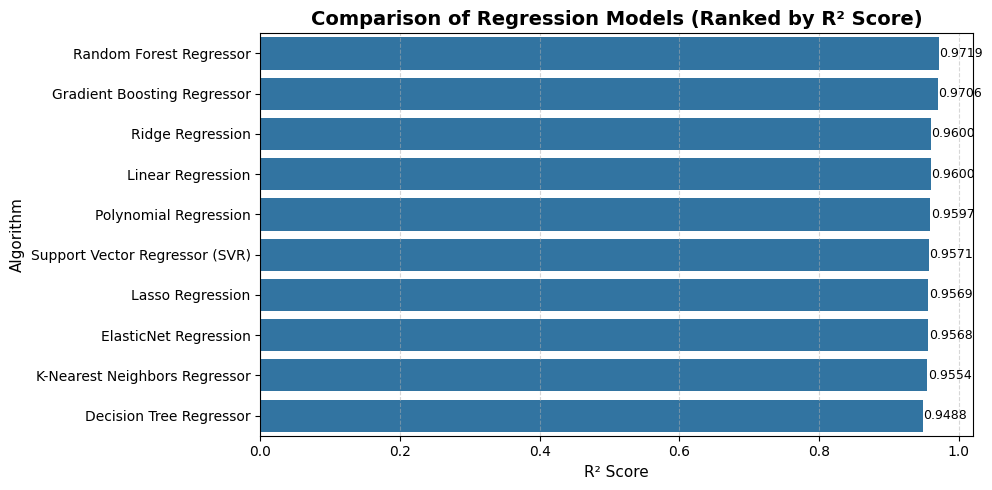

In [71]:
# ==========================================
# REGRESSION MODEL COMPARISON BAR PLOT
# ==========================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=regression_results,
    x='R2 Score',
    y='Algorithm'
)

plt.title(
    'Comparison of Regression Models (Ranked by R² Score)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('R² Score', fontsize=11)
plt.ylabel('Algorithm', fontsize=11)

# Add R² score labels
for index, value in enumerate(regression_results['R2 Score']):
    plt.text(
        value + 0.0005,
        index,
        f'{value:.4f}',
        va='center',
        fontsize=9
    )

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [72]:
# ==========================================
# 5-FOLD CROSS VALIDATION - TOP 2 MODELS
# Random Forest vs Gradient Boosting
# ==========================================

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# Use a sample for faster cross-validation
CV_SAMPLE_SIZE = 10000

X_cv = X_train_pca[:CV_SAMPLE_SIZE]
y_cv = y_train.iloc[:CV_SAMPLE_SIZE]

# ==========================================
# RANDOM FOREST - 5 FOLD CV
# ==========================================

cv_scores_rf = cross_val_score(
    rf_reg,
    X_cv,
    y_cv,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# ==========================================
# GRADIENT BOOSTING - 5 FOLD CV
# ==========================================

gb_cv = GradientBoostingRegressor(
    n_estimators=20,
    learning_rate=best_learning_rate,
    max_depth=2,
    random_state=RANDOM_STATE
)

cv_scores_gb = cross_val_score(
    gb_cv,
    X_cv,
    y_cv,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# ==========================================
# CREATE COMPARISON TABLE
# ==========================================

cv_comparison = pd.DataFrame({
    'Model': [
        'Random Forest Regressor',
        'Gradient Boosting Regressor'
    ],

    'Mean R² Score': [
        cv_scores_rf.mean(),
        cv_scores_gb.mean()
    ],

    'Standard Deviation': [
        cv_scores_rf.std(),
        cv_scores_gb.std()
    ],

    'Fold 1': [
        cv_scores_rf[0],
        cv_scores_gb[0]
    ],

    'Fold 2': [
        cv_scores_rf[1],
        cv_scores_gb[1]
    ],

    'Fold 3': [
        cv_scores_rf[2],
        cv_scores_gb[2]
    ],

    'Fold 4': [
        cv_scores_rf[3],
        cv_scores_gb[3]
    ],

    'Fold 5': [
        cv_scores_rf[4],
        cv_scores_gb[4]
    ]
})

# Sort based on Mean R² Score
cv_comparison = cv_comparison.sort_values(
    by='Mean R² Score',
    ascending=False
).reset_index(drop=True)

# ==========================================
# DISPLAY RESULTS
# ==========================================

print("5-FOLD CROSS VALIDATION - TOP 2 MODELS")

display(cv_comparison)

5-FOLD CROSS VALIDATION - TOP 2 MODELS


,Model,Mean R² Score,Standard Deviation,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Random Forest Regressor,0.955665,0.010593,0.938400,0.954104,0.953203,0.970041,0.962578
1,Gradient Boosting Regressor,0.945398,0.015966,0.915952,0.948388,0.944067,0.961612,0.956970


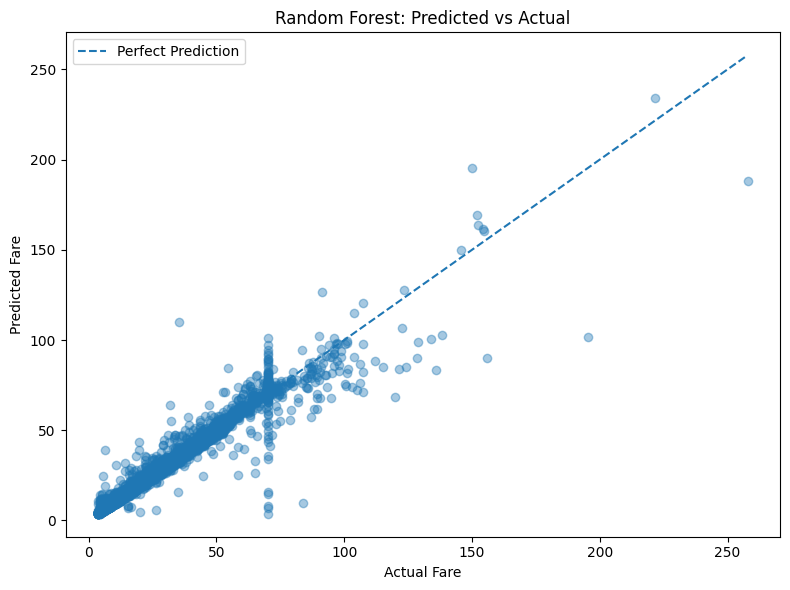

In [73]:
# ==========================================
# PREDICTED VS ACTUAL - BEST MODEL
# Random Forest Regressor
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.4)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Random Forest: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

### Predicted vs Actual Plot
The predicted fare values are generally close to the diagonal perfect-prediction line, indicating that the Random Forest model performs well on the test data. Most observations are concentrated around the diagonal, although some larger fare values show greater prediction errors.

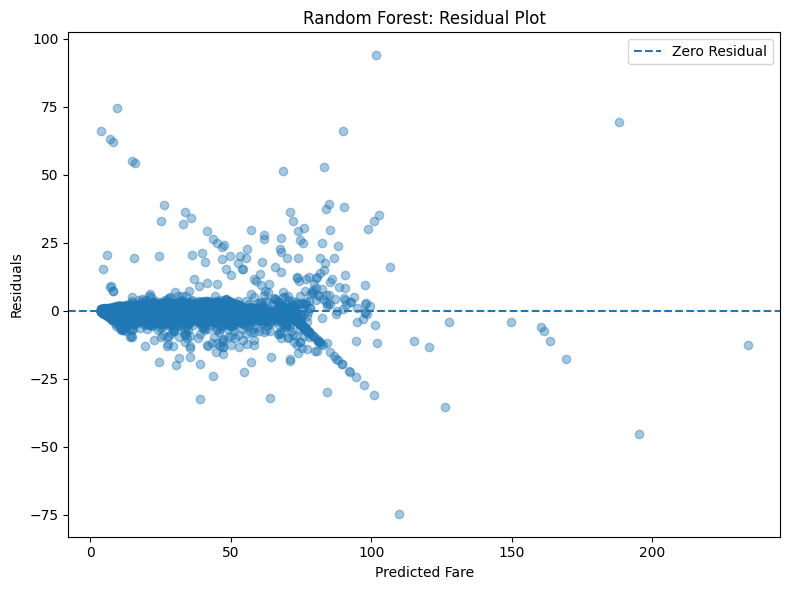

In [74]:
# ==========================================
# RESIDUAL PLOT - BEST MODEL
# Random Forest Regressor
# ==========================================

residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_rf, residuals, alpha=0.4)

plt.axhline(
    y=0,
    linestyle='--',
    label='Zero Residual'
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")
plt.legend()
plt.tight_layout()
plt.show()

### Residual Plot
Most residuals are distributed around the zero-residual line, indicating generally accurate predictions. However, the spread of residuals increases for higher predicted fare values, with a few noticeable outliers showing larger prediction errors.


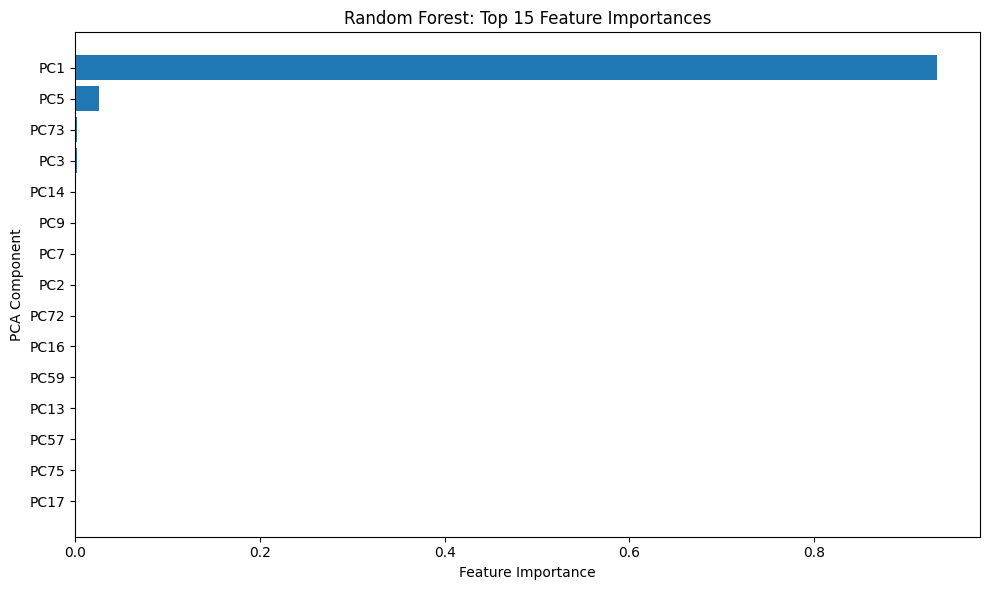

In [75]:
# ==========================================
# FEATURE IMPORTANCE
# Random Forest Regressor
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

feature_importance = rf_reg.feature_importances_

# Get top 15 PCA components
top_n = 15

indices = np.argsort(feature_importance)[-top_n:]

plt.figure(figsize=(10, 6))

plt.barh(
    range(top_n),
    feature_importance[indices]
)

plt.yticks(
    range(top_n),
    [f"PC{i+1}" for i in indices]
)

plt.xlabel("Feature Importance")
plt.ylabel("PCA Component")
plt.title("Random Forest: Top 15 Feature Importances")
plt.tight_layout()
plt.show()

### Feature Importance
The feature importance plot shows that **PC1** is the most influential PCA component for the Random Forest model, contributing substantially more than the other principal components. The remaining components have comparatively smaller importance values.